In [5]:
from google.colab import files
from IPython.display import display
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# ============================================================
# 1. UPLOAD FILE
# ============================================================

uploaded = files.upload()

csv_files = [file for file in os.listdir() if file.endswith(".csv")]

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file was uploaded.")

FILE_PATH = csv_files[0]
OUTPUT_DIR = "eda_results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(FILE_PATH)

df.columns = df.columns.astype(str).str.strip()

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

print("=" * 80)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 80)

print("Loaded file:", FILE_PATH)
print("Dataset shape:", df.shape)

display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

Saving drom_final_clean2.csv to drom_final_clean2.csv
DATASET LOADED SUCCESSFULLY
Loaded file: drom_final_clean2.csv
Dataset shape: (3402, 9)


,Title,Year,Engine,Fuel,Transmission,Drive,Mileage,Price,Location
0,bmw 1-series,2008,1.60,petrol,automatic,rear,"95,000.00",670000,москва
1,bmw 5-series,2019,2.00,diesel,automatic,rear,"115,000.00",2650000,москва
2,bmw 3-series,2016,2.00,petrol,automatic,awd,"130,000.00",2550000,москва
3,bmw x7,2020,3.00,diesel,automatic,awd,"79,740.00",10599000,москва
4,bmw 3-series,2020,2.00,petrol,automatic,rear,"93,000.00",4100000,москва



Column names:
['Title', 'Year', 'Engine', 'Fuel', 'Transmission', 'Drive', 'Mileage', 'Price', 'Location']

Data types:


,0
Title,object
Year,int64
Engine,float64
Fuel,object
Transmission,object
Drive,object
Mileage,float64
Price,int64
Location,object


In [ ]:
# ============================================================
# 2. CONVERT IMPORTANT COLUMNS TO NUMERIC
# ============================================================

important_numeric_cols = ["Year", "Engine", "Mileage", "Price"]

for col in important_numeric_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(" ", "", regex=False)
            .str.replace(",", ".", regex=False)
            .str.replace("₽", "", regex=False)
            .str.replace("руб.", "", regex=False)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nData types after conversion:")
display(df.dtypes)


Data types after conversion:


,0
Title,object
Year,int64
Engine,float64
Fuel,object
Transmission,object
Drive,object
Mileage,float64
Price,int64
Location,object


In [ ]:
# ============================================================
# 3. DATA QUALITY CHECK
# ============================================================

print("=" * 80)
print("DATA QUALITY CHECK")
print("=" * 80)

missing_values = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)
duplicates = df.duplicated().sum()

missing_table = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percent": missing_percent
})

print("\nMissing values:")
display(missing_table)

print("\nDuplicate rows:")
print(duplicates)

missing_table.to_csv(f"{OUTPUT_DIR}/missing_values.csv")

DATA QUALITY CHECK

Missing values:


,missing_count,missing_percent
Title,0,0.00
Year,0,0.00
Engine,2,0.06
Fuel,1,0.03
Transmission,2,0.06
Drive,2,0.06
Mileage,82,2.41
Price,0,0.00
Location,0,0.00



Duplicate rows:
0


In [ ]:
# ============================================================
# 4. COLUMN TYPES
# ============================================================

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("=" * 80)
print("COLUMN TYPES")
print("=" * 80)

print("Numerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

COLUMN TYPES
Numerical columns:
['Year', 'Engine', 'Mileage', 'Price']

Categorical columns:
['Title', 'Fuel', 'Transmission', 'Drive', 'Location']


In [ ]:
# ============================================================
# 5. DESCRIPTIVE STATISTICS
# ============================================================

print("=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)

if len(numeric_cols) > 0:
    desc_stats = pd.DataFrame({
        "mean": df[numeric_cols].mean(),
        "median": df[numeric_cols].median(),
        "mode": df[numeric_cols].mode().iloc[0],
        "std": df[numeric_cols].std(),
        "min": df[numeric_cols].min(),
        "25%": df[numeric_cols].quantile(0.25),
        "50%": df[numeric_cols].quantile(0.50),
        "75%": df[numeric_cols].quantile(0.75),
        "max": df[numeric_cols].max()
    })

    display(desc_stats)
    display(df[numeric_cols].describe())

    desc_stats.to_csv(f"{OUTPUT_DIR}/descriptive_statistics.csv")
    df[numeric_cols].describe().to_csv(f"{OUTPUT_DIR}/pandas_describe.csv")

DESCRIPTIVE STATISTICS


,mean,median,mode,std,min,25%,50%,75%,max
Year,"2,013.21","2,014.00","2,019.00",7.47,"1,980.00","2,009.00","2,014.00","2,019.00","2,026.00"
Engine,3.24,2.50,3.00,15.04,0.60,2.00,2.50,3.00,523.00
Mileage,"2,805,862.58","530,000.00","250,000.00","6,389,525.64",1.00,"171,000.00","530,000.00","2,200,000.00","82,635,200.00"
Price,"3,361,643.87","2,097,000.00","1,000,000.00","3,431,462.33","40,000.00","1,272,500.00","2,097,000.00","4,100,000.00","24,990,000.00"


,Year,Engine,Mileage,Price
count,"3,402.00","3,400.00","3,320.00","3,402.00"
mean,"2,013.21",3.24,"2,805,862.58","3,361,643.87"
std,7.47,15.04,"6,389,525.64","3,431,462.33"
min,"1,980.00",0.60,1.00,"40,000.00"
25%,"2,009.00",2.00,"171,000.00","1,272,500.00"
50%,"2,014.00",2.50,"530,000.00","2,097,000.00"
75%,"2,019.00",3.00,"2,200,000.00","4,100,000.00"
max,"2,026.00",523.00,"82,635,200.00","24,990,000.00"


In [ ]:
# ============================================================
# 6. CATEGORICAL VARIABLES SUMMARY
# ============================================================

print("=" * 80)
print("CATEGORICAL VARIABLES SUMMARY")
print("=" * 80)

for col in categorical_cols:
    print("\n" + "-" * 80)
    print(f"Column: {col}")
    print(f"Unique values: {df[col].nunique()}")
    print("Top 10 values:")
    display(df[col].value_counts().head(10))

    safe_col = col.replace("/", "_").replace("\\", "_").replace(" ", "_")
    df[col].value_counts().head(20).to_csv(
        f"{OUTPUT_DIR}/top_values_{safe_col}.csv",
        header=["count"]
    )

CATEGORICAL VARIABLES SUMMARY

--------------------------------------------------------------------------------
Column: Title
Unique values: 27
Top 10 values:


,count
Title,
bmw 5-series,743
bmw x5,635
bmw 3-series,515
bmw x3,290
bmw x6,278
bmw x1,171
bmw 1-series,168
bmw 7-series,136
bmw x7,103



--------------------------------------------------------------------------------
Column: Fuel
Unique values: 6
Top 10 values:


,count
Fuel,
petrol,2146
diesel,1095
hybrid,147
electric,10
автомат,2
157 000 км,1



--------------------------------------------------------------------------------
Column: Transmission
Unique values: 5
Top 10 values:


,count
Transmission,
automatic,3115
manual,179
robot,104
задний,1
4wd,1



--------------------------------------------------------------------------------
Column: Drive
Unique values: 6
Top 10 values:


,count
Drive,
awd,2099
rear,1185
front,113
352 000 км,1
57 900 км,1
73 500 км,1



--------------------------------------------------------------------------------
Column: Location
Unique values: 258
Top 10 values:


,count
Location,
москва,613
новосибирск,229
санкт-петербург,158
краснодар,150
красноярск,129
владивосток,107
тюмень,102
екатеринбург,90
иркутск,86


DISTRIBUTION ANALYSIS

Column: Year
Skewness: -0.76


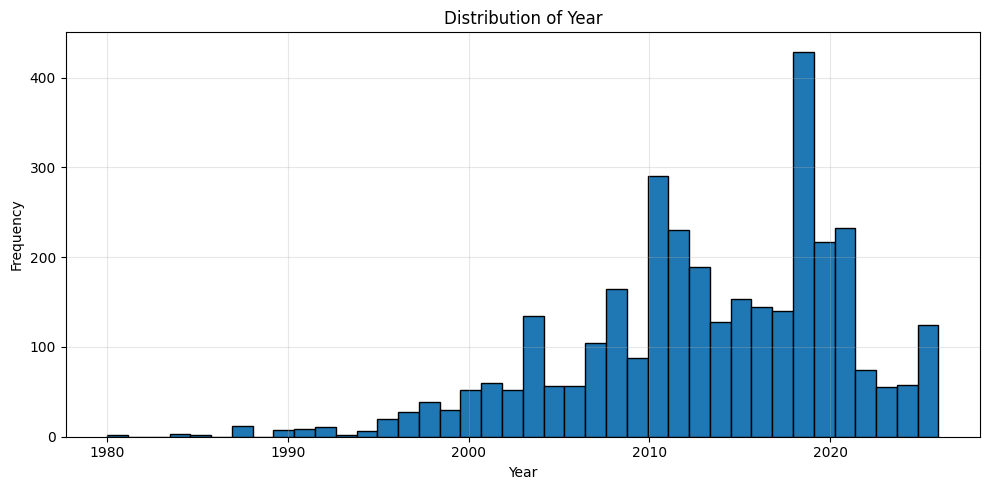

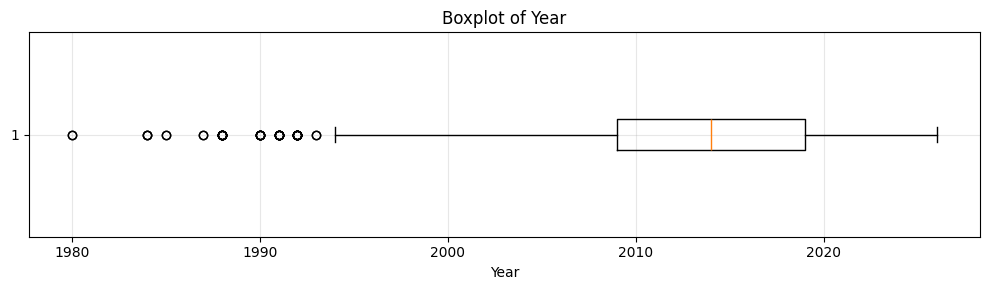


Column: Engine
Skewness: 27.789


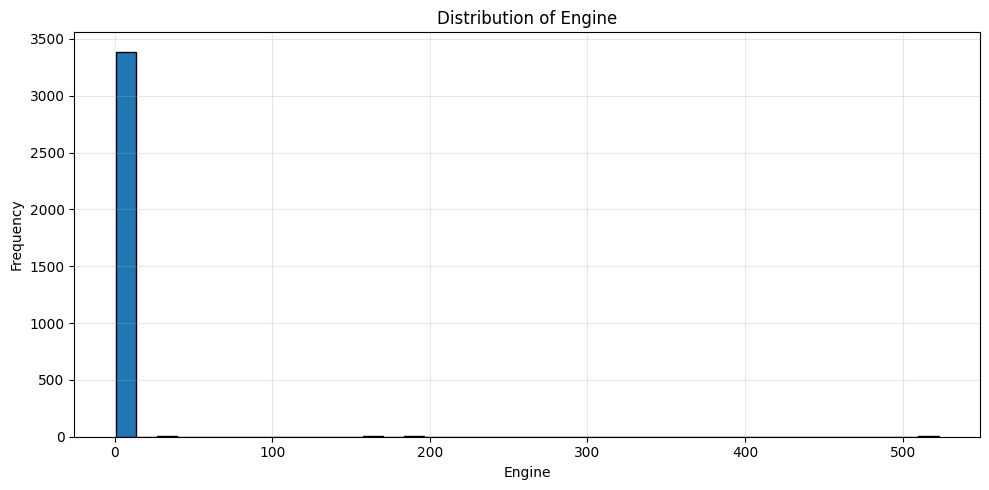

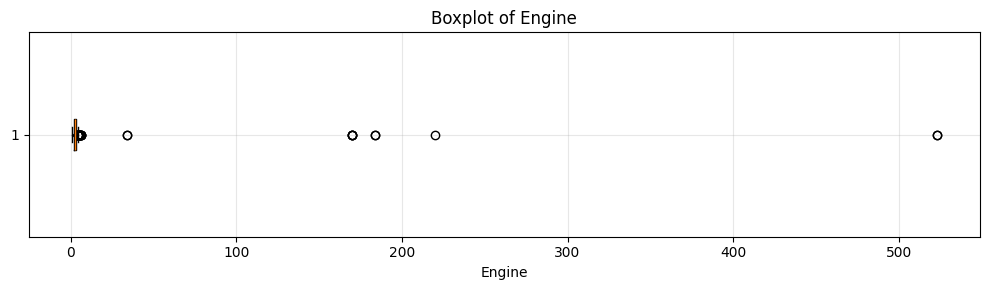


Column: Mileage
Skewness: 4.037


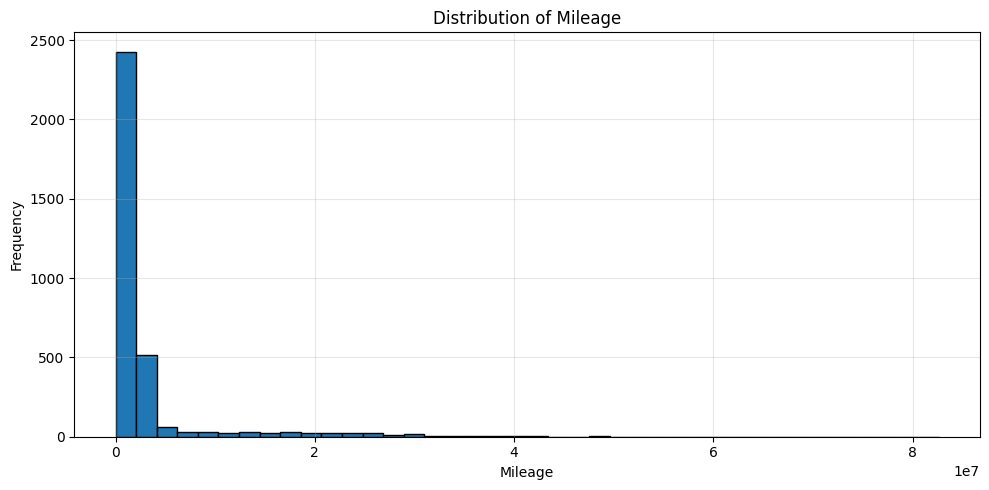

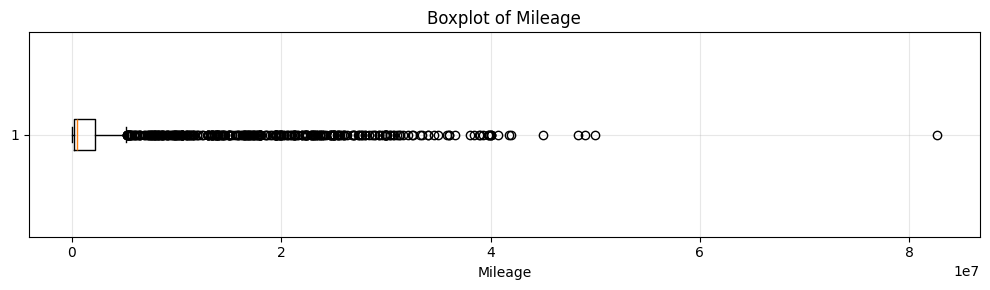


Column: Price
Skewness: 2.383


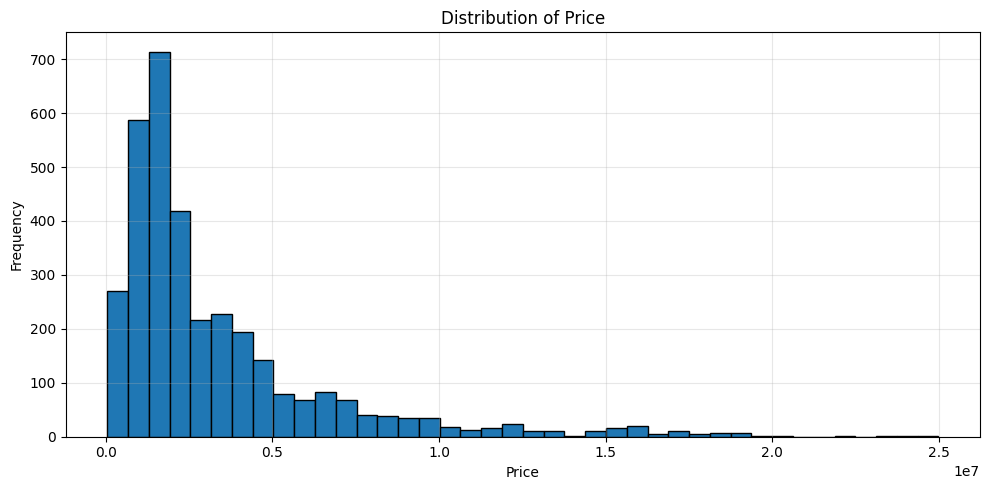

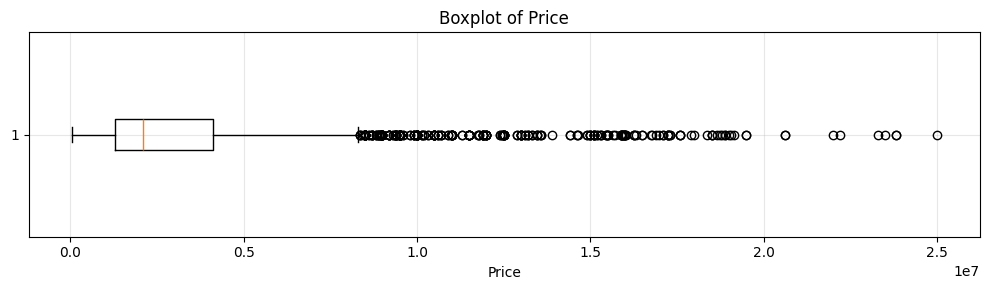

In [ ]:
# ============================================================
# 7. DISTRIBUTION ANALYSIS
# ============================================================

print("=" * 80)
print("DISTRIBUTION ANALYSIS")
print("=" * 80)

for col in numeric_cols:
    data = df[col].dropna()

    if len(data) == 0:
        continue

    print(f"\nColumn: {col}")
    print(f"Skewness: {round(data.skew(), 3)}")

    safe_col = col.replace("/", "_").replace("\\", "_").replace(" ", "_")

    plt.figure(figsize=(10, 5))
    plt.hist(data, bins=40, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/distribution_{safe_col}.png", dpi=300)
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.boxplot(data, vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/boxplot_{safe_col}.png", dpi=300)
    plt.show()

PRICE DISTRIBUTION
Price skewness: 2.383
Log Price skewness: -0.02


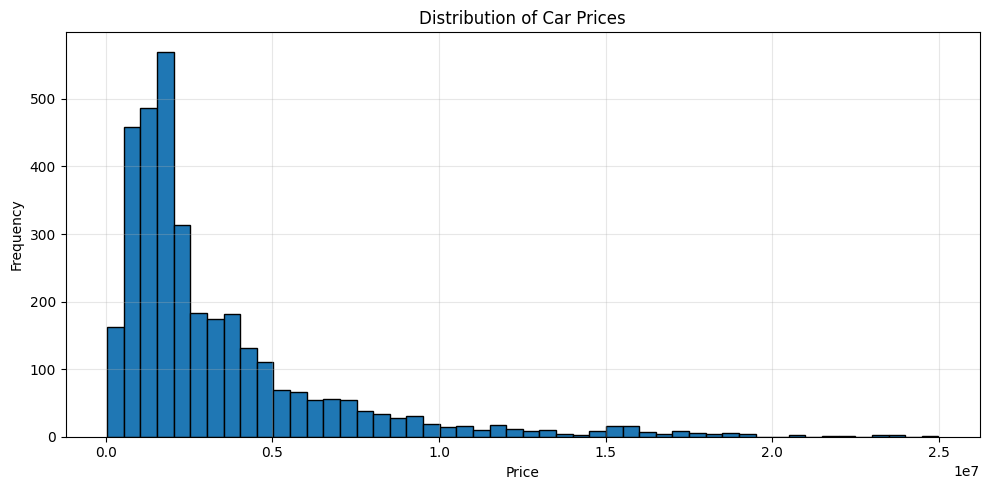

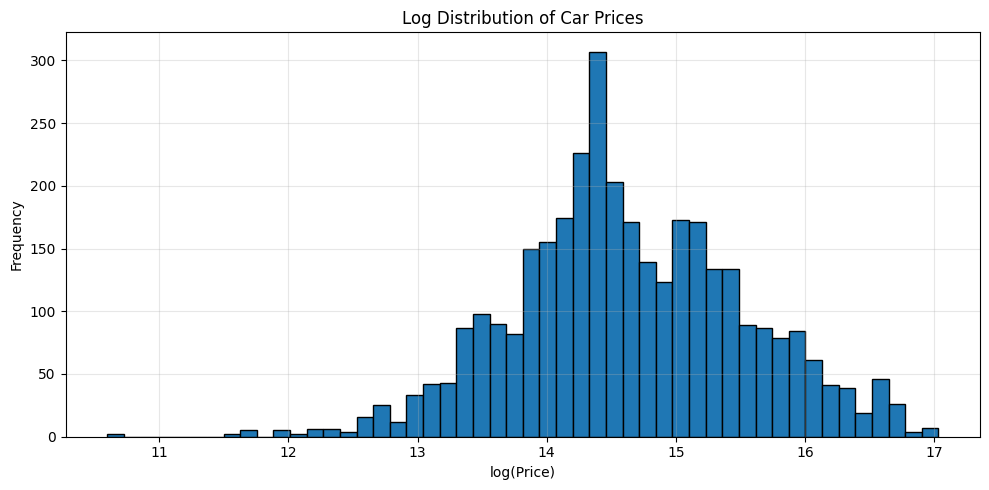

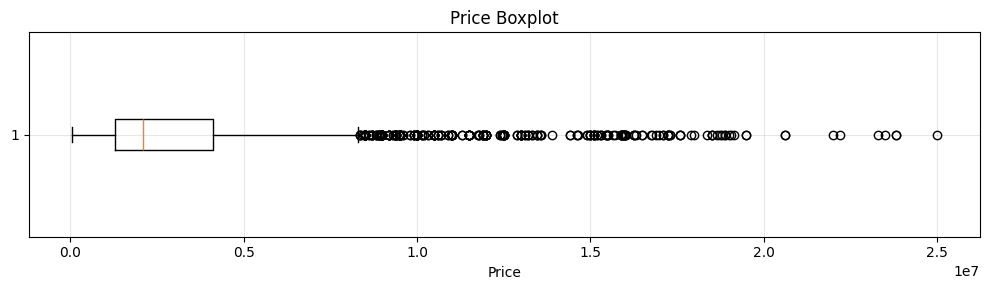

In [ ]:
# ============================================================
# 8. PRICE DISTRIBUTION
# ============================================================

print("=" * 80)
print("PRICE DISTRIBUTION")
print("=" * 80)

if "Price" in df.columns:
    price_data = df["Price"].dropna()

    print("Price skewness:", round(price_data.skew(), 3))
    print("Log Price skewness:", round(np.log1p(price_data).skew(), 3))

    plt.figure(figsize=(10, 5))
    plt.hist(price_data, bins=50, edgecolor="black")
    plt.title("Distribution of Car Prices")
    plt.xlabel("Price")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/price_distribution.png", dpi=300)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.hist(np.log1p(price_data), bins=50, edgecolor="black")
    plt.title("Log Distribution of Car Prices")
    plt.xlabel("log(Price)")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/log_price_distribution.png", dpi=300)
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.boxplot(price_data, vert=False)
    plt.title("Price Boxplot")
    plt.xlabel("Price")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/price_boxplot.png", dpi=300)
    plt.show()


CORRELATION ANALYSIS
Correlation matrix:


,Year,Engine,Mileage,Price
Year,1.00,0.03,-0.19,0.67
Engine,0.03,1.00,-0.02,0.04
Mileage,-0.19,-0.02,1.00,-0.16
Price,0.67,0.04,-0.16,1.00



Correlation with Price:


,Price
Price,1.00
Year,0.67
Engine,0.04
Mileage,-0.16


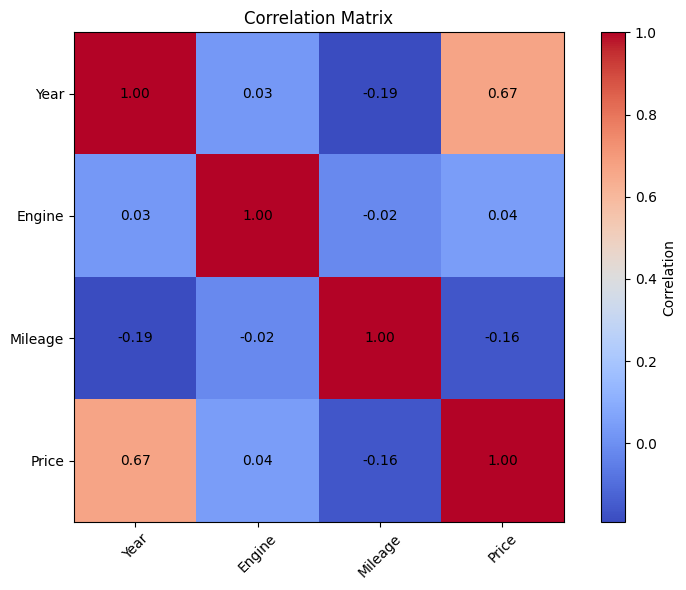

In [ ]:
# ============================================================
# 9. CORRELATION ANALYSIS
# ============================================================

print("=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

if len(numeric_cols) > 1:
    corr_matrix = df[numeric_cols].corr()

    print("Correlation matrix:")
    display(corr_matrix)

    corr_matrix.to_csv(f"{OUTPUT_DIR}/correlation_matrix.csv")

    if "Price" in numeric_cols:
        print("\nCorrelation with Price:")
        price_corr = corr_matrix["Price"].sort_values(ascending=False)
        display(price_corr)
        price_corr.to_csv(f"{OUTPUT_DIR}/correlation_with_price.csv", header=["correlation"])

    plt.figure(figsize=(8, 6))
    plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
    plt.colorbar(label="Correlation")

    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
    plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

    for i in range(len(corr_matrix.columns)):
        for j in range(len(corr_matrix.columns)):
            plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")

    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/correlation_matrix.png", dpi=300)
    plt.show()

SCATTERPLOTS WITH PRICE


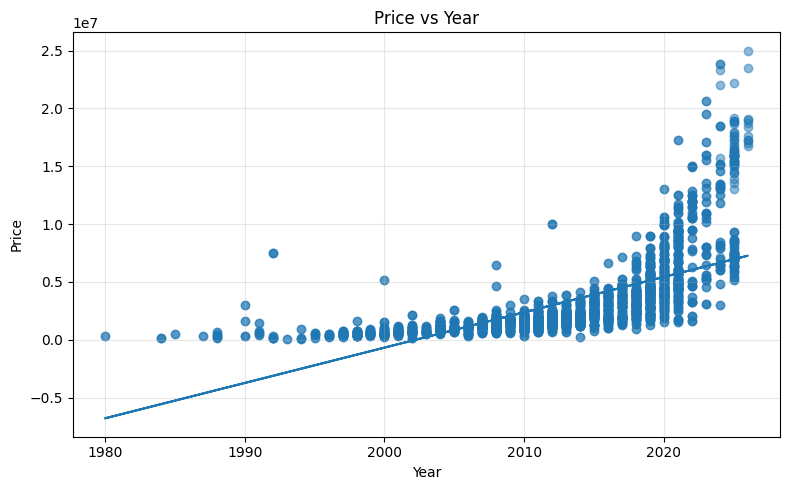

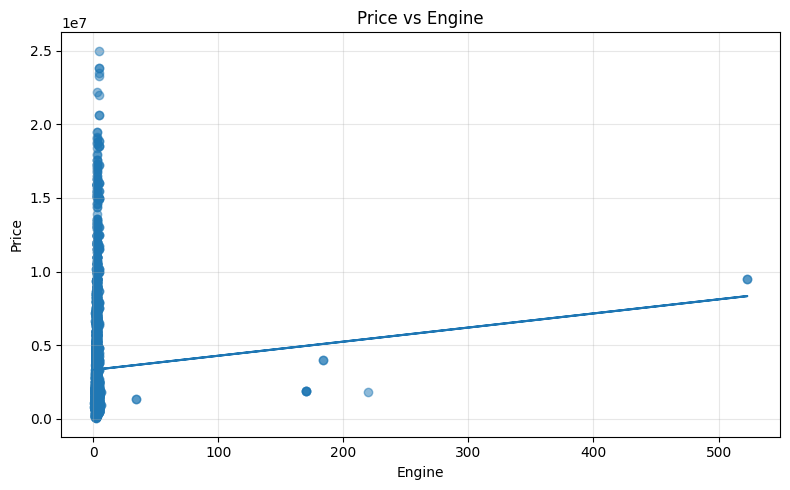

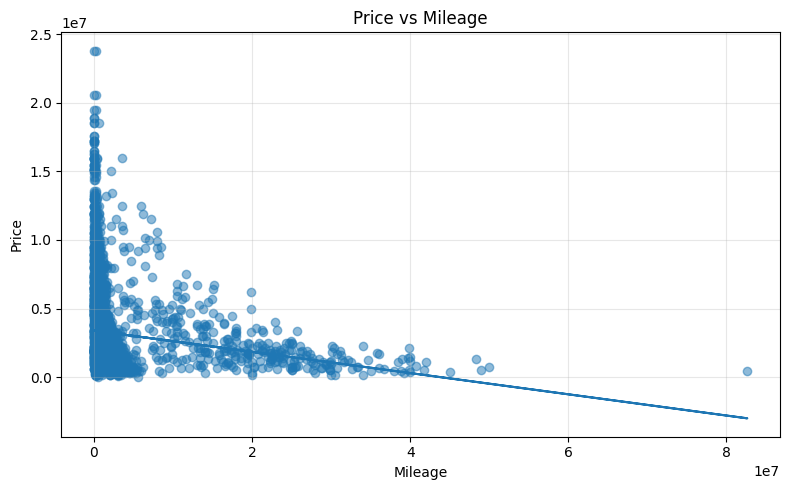

In [ ]:
#============================================================
# 10 . SCATTERPLOTS WITH PRICE
# ============================================================

print("=" * 80)
print("SCATTERPLOTS WITH PRICE")
print("=" * 80)

if "Price" in numeric_cols:
    for col in numeric_cols:
        if col != "Price":
            clean_data = df[[col, "Price"]].dropna()

            if len(clean_data) == 0:
                continue

            plt.figure(figsize=(8, 5))
            plt.scatter(clean_data[col], clean_data["Price"], alpha=0.5)

            if len(clean_data) > 1:
                z = np.polyfit(clean_data[col], clean_data["Price"], 1)
                p = np.poly1d(z)
                plt.plot(clean_data[col], p(clean_data[col]))

            plt.title(f"Price vs {col}")
            plt.xlabel(col)
            plt.ylabel("Price")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(f"{OUTPUT_DIR}/scatter_price_vs_{col}.png", dpi=300)
            plt.show()

GROUP-BY ANALYSIS

--------------------------------------------------------------------------------
Average price by Title:


,count,mean_price,median_price,min_price,max_price
Title,,,,,
bmw xm,7,"19,542,857.14","20,600,000.00",16000000,23800000
bmw m5,17,"13,600,000.00","14,900,000.00",6500000,18500000
bmw x7,103,"11,264,192.00","10,300,000.00",6049888,23490000
bmw m4,7,"10,771,428.57","9,500,000.00",8250000,15200000
bmw m3,7,"10,427,142.86","10,000,000.00",9595000,11900000
bmw ix,2,"9,500,000.00","9,500,000.00",9500000,9500000
bmw 8-series,15,"7,769,866.67","7,500,000.00",6290000,10000000
bmw i8,4,"6,924,500.00","6,924,500.00",6650000,7199000
bmw 6-series gran turismo,8,"4,651,250.00","4,307,500.00",3700000,6290000


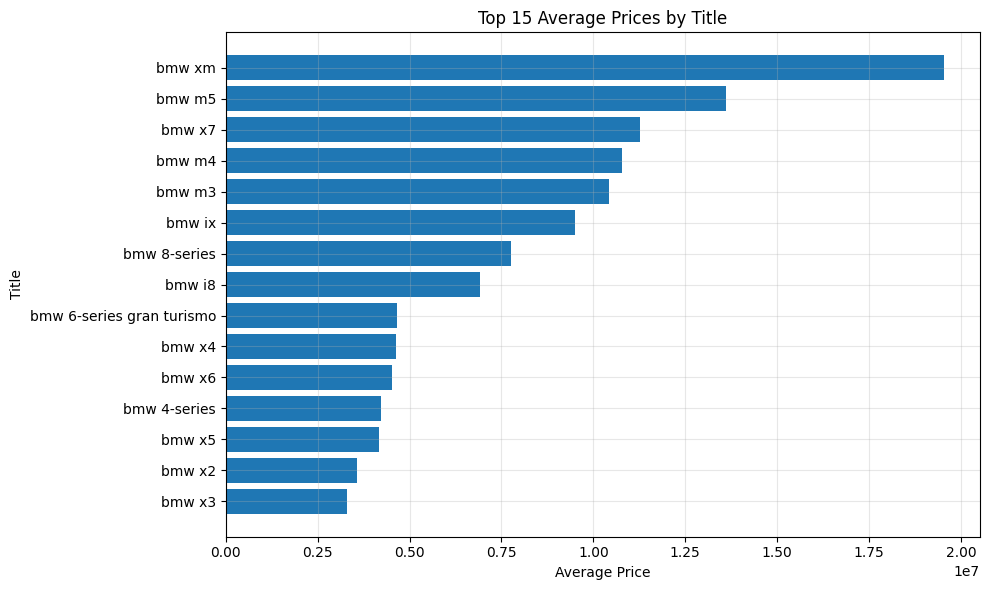


--------------------------------------------------------------------------------
Average price by Fuel:


,count,mean_price,median_price,min_price,max_price
Fuel,,,,,
hybrid,147,"10,347,835.21","9,350,000.00",796000,23800000
diesel,1095,"4,152,817.46","3,450,000.00",240000,18800000
electric,10,"3,730,000.00","1,900,000.00",1350000,9500000
petrol,2146,"2,480,053.85","1,619,000.00",40000,24990000
автомат,2,"2,225,000.00","2,225,000.00",800000,3650000
157 000 км,1,"2,100,000.00","2,100,000.00",2100000,2100000


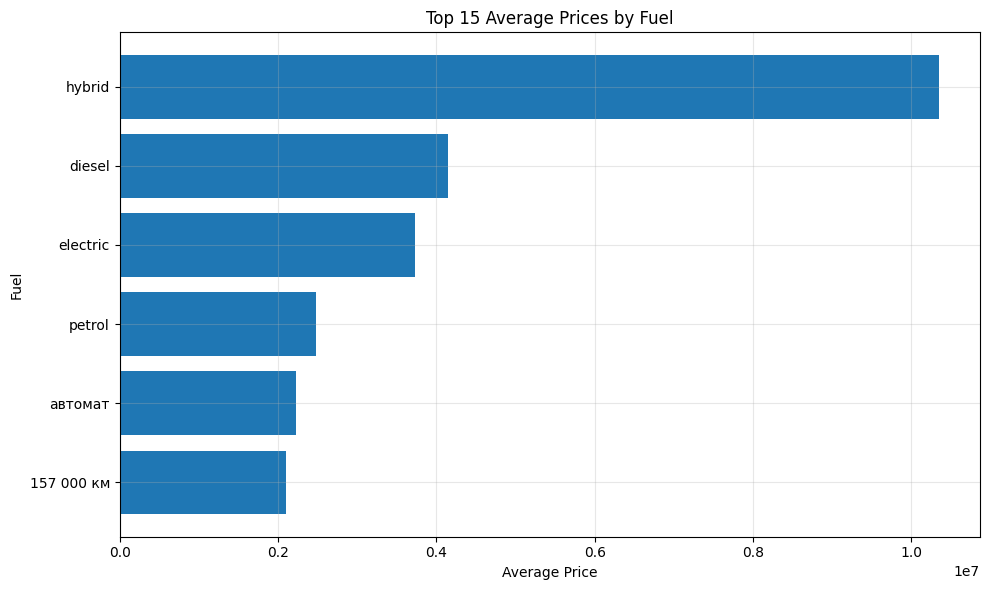


--------------------------------------------------------------------------------
Average price by Transmission:


,count,mean_price,median_price,min_price,max_price
Transmission,,,,,
4wd,1,"3,650,000.00","3,650,000.00",3650000,3650000
robot,104,"3,571,287.50","2,570,000.00",1250000,10000000
automatic,3115,"3,510,202.64","2,150,000.00",40000,24990000
задний,1,"800,000.00","800,000.00",800000,800000
manual,179,"683,057.82","549,999.00",120000,4690000


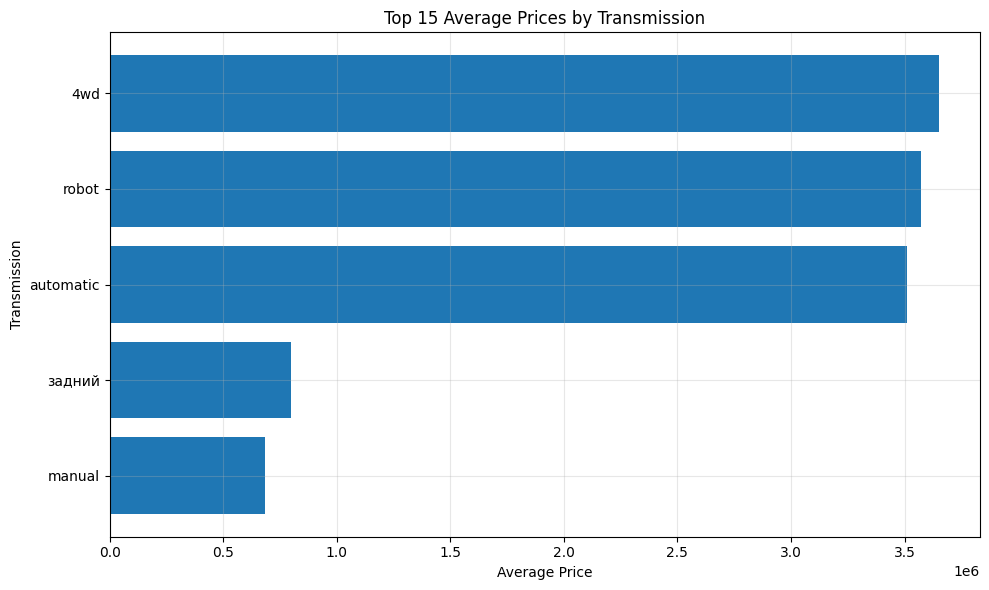


--------------------------------------------------------------------------------
Average price by Drive:


,count,mean_price,median_price,min_price,max_price
Drive,,,,,
73 500 км,1,"6,690,000.00","6,690,000.00",6690000,6690000
awd,2099,"4,402,685.85","3,110,000.00",300000,24990000
57 900 км,1,"3,650,000.00","3,650,000.00",3650000,3650000
front,113,"2,035,858.41","1,995,000.00",970000,6000000
rear,1185,"1,645,555.17","1,249,999.00",40000,10208000
352 000 км,1,"800,000.00","800,000.00",800000,800000


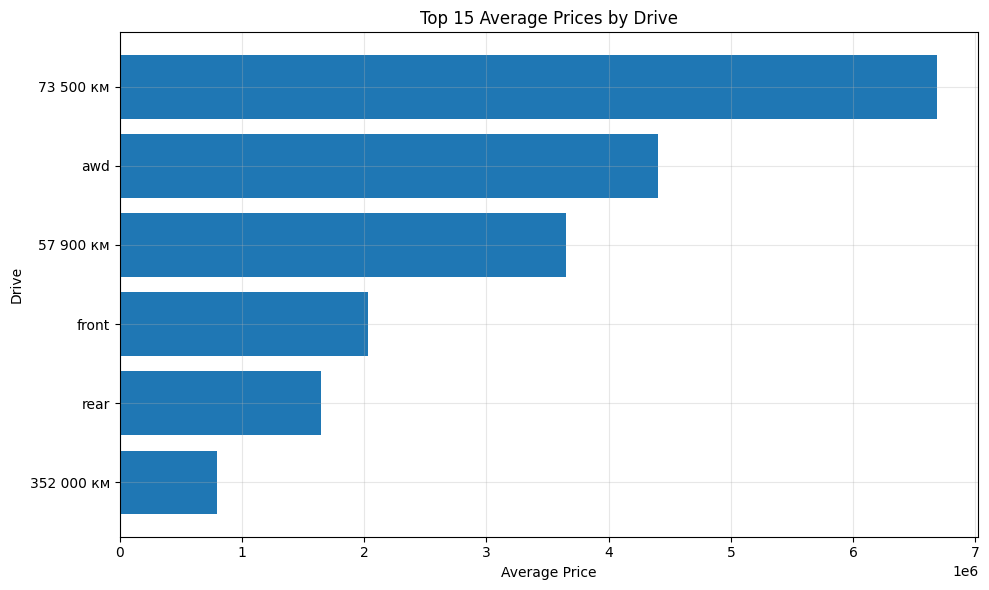


--------------------------------------------------------------------------------
Average price by Location:


,count,mean_price,median_price,min_price,max_price
Location,,,,,
корея→иркутск,2,"14,400,000.00","14,400,000.00",14400000,14400000
нягань,4,"11,174,000.00","12,999,000.00",5699000,12999000
южно-сахалинск,2,"9,000,000.00","9,000,000.00",9000000,9000000
нефтеюганск,2,"8,500,000.00","8,500,000.00",8500000,8500000
гвардейское,2,"8,500,000.00","8,500,000.00",8500000,8500000
новочебоксарск,2,"7,500,000.00","7,500,000.00",7500000,7500000
брюховецкая,2,"6,999,999.00","6,999,999.00",6999999,6999999
миасс,2,"6,300,000.00","6,300,000.00",6300000,6300000
артём,2,"6,150,000.00","6,150,000.00",6150000,6150000


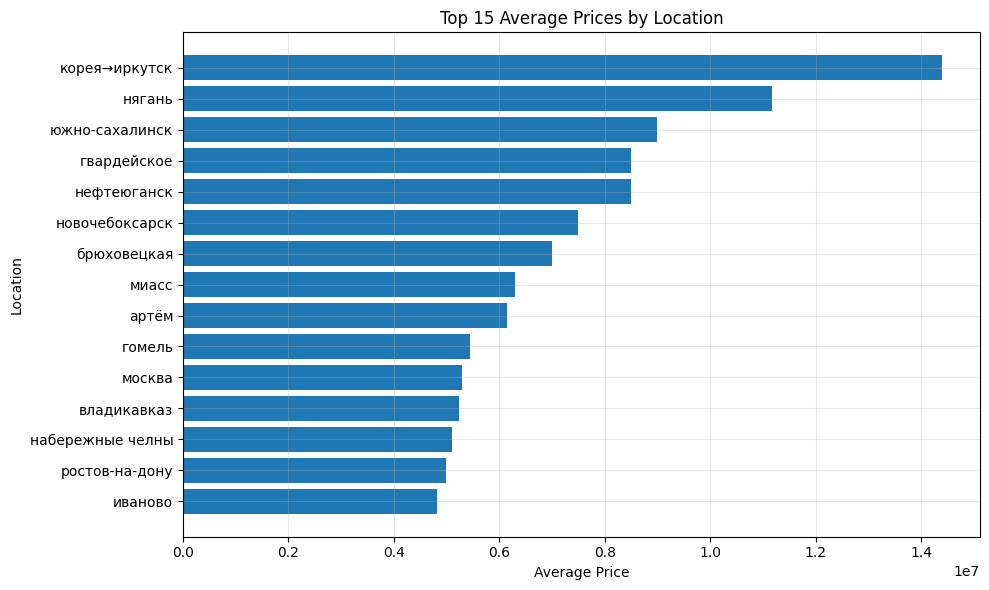

In [ ]:
# ============================================================
# 11. GROUP-BY ANALYSIS
# ============================================================

print("=" * 80)
print("GROUP-BY ANALYSIS")
print("=" * 80)

def group_price_analysis(dataframe, column):
    return (
        dataframe.groupby(column)
        .agg(
            count=("Price", "count"),
            mean_price=("Price", "mean"),
            median_price=("Price", "median"),
            min_price=("Price", "min"),
            max_price=("Price", "max")
        )
        .sort_values("mean_price", ascending=False)
    )

if "Price" in df.columns:
    for col in categorical_cols:
        print("\n" + "-" * 80)
        print(f"Average price by {col}:")

        result = group_price_analysis(df, col)
        display(result.head(15))

        safe_col = col.replace("/", "_").replace("\\", "_").replace(" ", "_")
        result.to_csv(f"{OUTPUT_DIR}/groupby_price_by_{safe_col}.csv")

        top_result = result.head(15).sort_values("mean_price")

        plt.figure(figsize=(10, 6))
        plt.barh(top_result.index.astype(str), top_result["mean_price"])
        plt.title(f"Top 15 Average Prices by {col}")
        plt.xlabel("Average Price")
        plt.ylabel(col)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/groupby_price_by_{safe_col}.png", dpi=300)
        plt.show()


YEAR ANALYSIS


,count,mean_price,median_price,mean_mileage
Year,,,,
1980,2,"300,000.00","300,000.00","1,375,000.00"
1984,3,"120,000.00","120,000.00","11,263,318.00"
1985,2,"500,000.00","500,000.00","2,090,000.00"
1987,2,"300,000.00","300,000.00","1,650,000.00"
1988,10,"397,800.00","420,000.00","1,526,800.00"
1990,7,"1,464,285.71","1,600,000.00","7,902,571.43"
1991,9,"811,111.11","610,000.00","5,495,500.00"
1992,11,"2,212,727.27","190,000.00","6,476,090.91"
1993,2,"40,000.00","40,000.00","3,096,500.00"


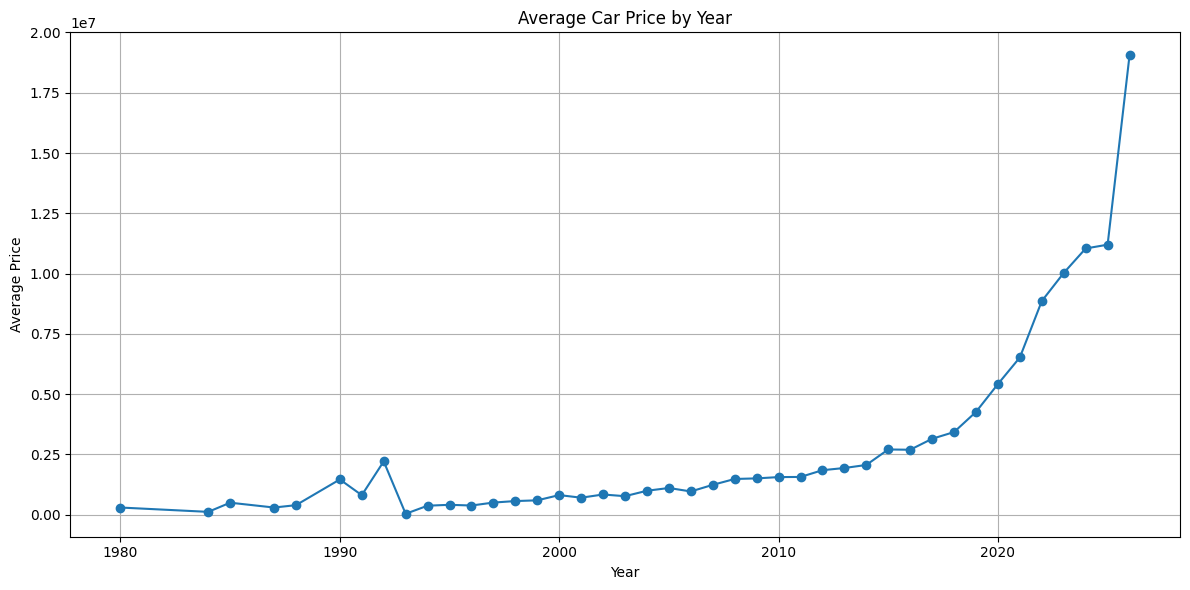

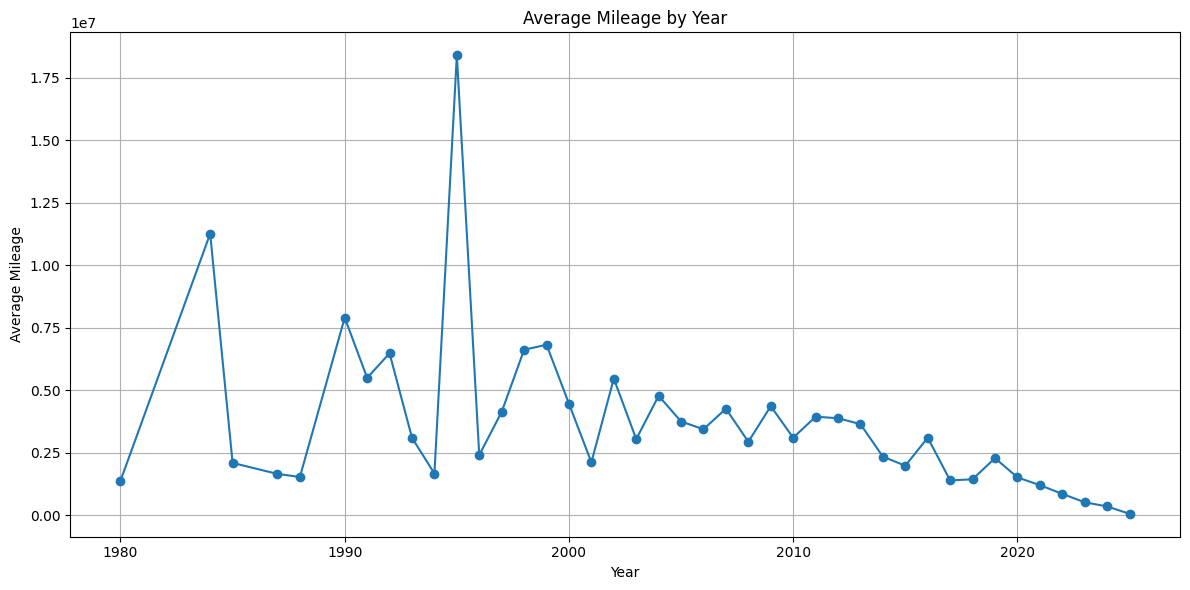

In [ ]:
# ============================================================
# 12. YEAR ANALYSIS
# ============================================================

print("=" * 80)
print("YEAR ANALYSIS")
print("=" * 80)

if all(col in df.columns for col in ["Year", "Price", "Mileage"]):
    year_price = (
        df.groupby("Year")
        .agg(
            count=("Price", "count"),
            mean_price=("Price", "mean"),
            median_price=("Price", "median"),
            mean_mileage=("Mileage", "mean")
        )
        .sort_index()
    )

    display(year_price)
    year_price.to_csv(f"{OUTPUT_DIR}/year_analysis.csv")

    plt.figure(figsize=(12, 6))
    plt.plot(year_price.index, year_price["mean_price"], marker="o")
    plt.title("Average Car Price by Year")
    plt.xlabel("Year")
    plt.ylabel("Average Price")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/average_price_by_year.png", dpi=300)
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(year_price.index, year_price["mean_mileage"], marker="o")
    plt.title("Average Mileage by Year")
    plt.xlabel("Year")
    plt.ylabel("Average Mileage")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/average_mileage_by_year.png", dpi=300)
    plt.show()

In [ ]:
# ============================================================
# 13. TOP-N AND BOTTOM-N RECORDS
# ============================================================

print("=" * 80)
print("TOP-N AND BOTTOM-N RECORDS")
print("=" * 80)

if "Price" in df.columns:
    top_expensive = df.sort_values("Price", ascending=False).head(10)
    top_cheapest = df.sort_values("Price", ascending=True).head(10)

    print("\nTop 10 most expensive cars:")
    display(top_expensive)

    print("\nTop 10 cheapest cars:")
    display(top_cheapest)

    top_expensive.to_csv(f"{OUTPUT_DIR}/top_10_expensive.csv", index=False)
    top_cheapest.to_csv(f"{OUTPUT_DIR}/top_10_cheapest.csv", index=False)

if "Mileage" in df.columns:
    top_mileage = df.sort_values("Mileage", ascending=False).head(10)

    print("\nTop 10 cars with highest mileage:")
    display(top_mileage)

    top_mileage.to_csv(f"{OUTPUT_DIR}/top_10_highest_mileage.csv", index=False)

if "Year" in df.columns:
    top_newest = df.sort_values("Year", ascending=False).head(10)
    top_oldest = df.sort_values("Year", ascending=True).head(10)

    print("\nTop 10 newest cars:")
    display(top_newest)

    print("\nTop 10 oldest cars:")
    display(top_oldest)

    top_newest.to_csv(f"{OUTPUT_DIR}/top_10_newest.csv", index=False)
    top_oldest.to_csv(f"{OUTPUT_DIR}/top_10_oldest.csv", index=False)

TOP-N AND BOTTOM-N RECORDS

Top 10 most expensive cars:


,Title,Year,Engine,Fuel,Transmission,Drive,Mileage,Price,Location
1361,bmw x5,2026,4.40,petrol,automatic,awd,NaN,24990000,москва
1074,bmw xm,2024,4.40,hybrid,automatic,awd,"26,300.00",23800000,москва
2567,bmw xm,2024,4.40,hybrid,automatic,awd,"263,000.00",23800000,москва
35,bmw x7,2026,4.40,hybrid,automatic,awd,NaN,23490000,москва
857,bmw x6,2024,4.40,hybrid,automatic,awd,NaN,23300000,москва
903,bmw 7-series,2025,3.00,hybrid,automatic,awd,NaN,22200000,москва
212,bmw x6,2024,4.40,petrol,automatic,awd,NaN,21990000,магнитогорск
2129,bmw xm,2023,4.40,hybrid,automatic,awd,"293,700.00",20600000,новосибирск
611,bmw xm,2023,4.40,hybrid,automatic,awd,"29,370.00",20600000,новосибирск
1302,bmw 7-series,2023,3.00,hybrid,automatic,awd,"26,298.00",19500000,краснодар



Top 10 cheapest cars:


,Title,Year,Engine,Fuel,Transmission,Drive,Mileage,Price,Location
937,bmw 5-series,1993,2.00,petrol,automatic,rear,"563,000.00",40000,гвардейск
2435,bmw 5-series,1993,2.00,petrol,automatic,rear,"5,630,000.00",40000,гвардейск
2824,bmw 3-series,1994,1.60,petrol,automatic,rear,"3,000,000.00",100000,калининград
1341,bmw 3-series,1994,1.60,petrol,automatic,rear,"300,000.00",100000,калининград
3232,bmw 3-series,1984,2.00,petrol,manual,rear,"30,441,400.00",120000,сочи
1762,bmw 3-series,1984,2.00,petrol,manual,rear,"3,044,140.00",120000,сочи
218,bmw 3-series,1984,2.00,petrol,manual,rear,"304,414.00",120000,сочи
543,bmw 5-series,1994,2.50,petrol,automatic,rear,"200,000.00",127000,чита
2062,bmw 5-series,1994,2.50,petrol,automatic,rear,"2,000,000.00",127000,чита
131,bmw 3-series,2002,2.00,petrol,manual,rear,"340,000.00",150000,северобайкальск



Top 10 cars with highest mileage:


,Title,Year,Engine,Fuel,Transmission,Drive,Mileage,Price,Location
3106,bmw 5-series,1995,2.00,petrol,manual,rear,"82,635,200.00",450000,челябинск
3199,bmw 5-series,1998,2.80,petrol,manual,rear,"50,000,000.00",750000,чита
3318,bmw 5-series,1995,2.50,diesel,manual,rear,"49,000,000.00",550000,евпатория
3235,bmw 5-series,2009,2.50,petrol,automatic,rear,"48,318,800.00",1289000,волгоград
3189,bmw 5-series,1990,2.50,petrol,manual,rear,"45,000,000.00",350000,саянск
3052,bmw x5,2004,3.00,petrol,automatic,awd,"42,000,000.00",1100000,волгоград
3142,bmw 5-series,1999,2.00,petrol,automatic,rear,"41,790,000.00",500000,москва
3068,bmw 5-series,2004,2.20,petrol,automatic,rear,"40,700,000.00",800000,орел
3131,bmw x5,2000,3.00,petrol,automatic,awd,"40,000,000.00",1500000,барнаул
3257,bmw 3-series,2000,2.00,petrol,manual,rear,"40,000,000.00",390000,москва



Top 10 newest cars:


,Title,Year,Engine,Fuel,Transmission,Drive,Mileage,Price,Location
1266,bmw x5,2026,3.00,diesel,automatic,awd,NaN,16790000,москва
1361,bmw x5,2026,4.40,petrol,automatic,awd,NaN,24990000,москва
814,bmw x7,2026,3.00,hybrid,automatic,awd,NaN,18750000,москва
852,bmw x5,2026,3.00,hybrid,automatic,awd,NaN,17590000,москва
1439,bmw x5,2026,3.00,diesel,automatic,awd,NaN,16990000,москва
1512,bmw x5,2026,3.00,diesel,automatic,awd,NaN,17290000,москва
720,bmw x5,2026,3.00,diesel,automatic,awd,NaN,17283000,новосибирск
708,bmw x7,2026,3.00,hybrid,automatic,awd,NaN,19060000,новосибирск
667,bmw x7,2026,3.00,hybrid,automatic,awd,NaN,18990000,москва
637,bmw x5,2026,3.00,petrol,automatic,awd,NaN,18375000,москва



Top 10 oldest cars:


,Title,Year,Engine,Fuel,Transmission,Drive,Mileage,Price,Location
2300,bmw 5-series,1980,2.00,petrol,automatic,rear,"2,500,000.00",300000,могзон
793,bmw 5-series,1980,2.00,petrol,automatic,rear,"250,000.00",300000,могзон
218,bmw 3-series,1984,2.00,petrol,manual,rear,"304,414.00",120000,сочи
3232,bmw 3-series,1984,2.00,petrol,manual,rear,"30,441,400.00",120000,сочи
1762,bmw 3-series,1984,2.00,petrol,manual,rear,"3,044,140.00",120000,сочи
798,bmw 5-series,1985,2.70,petrol,automatic,rear,"380,000.00",500000,анапа
2305,bmw 5-series,1985,2.70,petrol,automatic,rear,"3,800,000.00",500000,анапа
886,bmw 5-series,1987,2.00,petrol,manual,rear,"300,000.00",300000,тобольск
2386,bmw 5-series,1987,2.00,petrol,manual,rear,"3,000,000.00",300000,тобольск
2272,bmw 5-series,1988,2.00,petrol,manual,rear,"2,910,000.00",250000,кемерово


HYPOTHESIS 1
Hypothesis 1: Newer cars are more expensive.
Correlation between Year and Price: 0.666
Conclusion: Supported. Newer cars generally have higher prices.


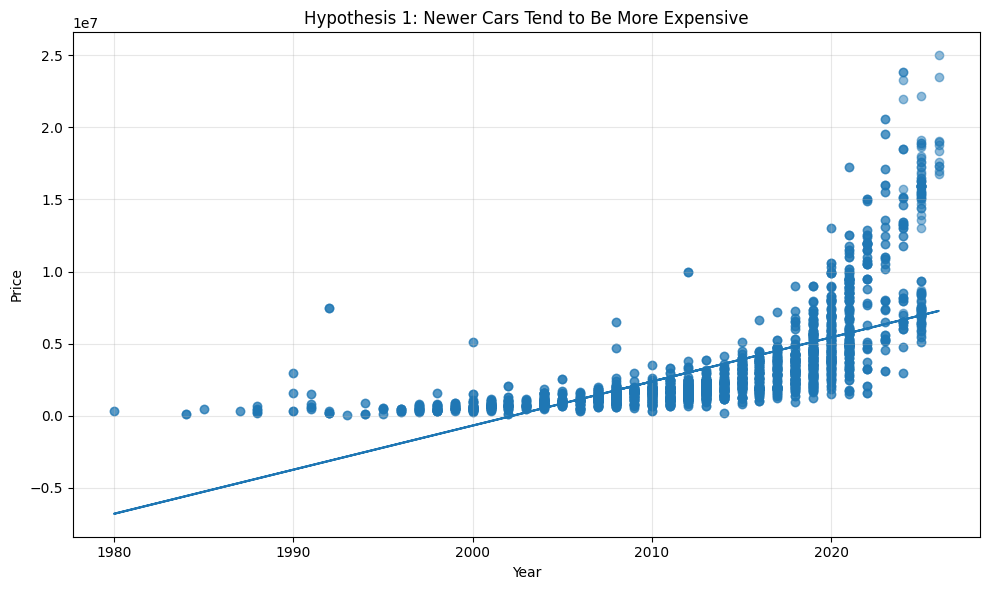

In [ ]:
# ============================================================
# 14. HYPOTHESIS 1
# Newer cars are more expensive
# ============================================================

print("=" * 80)
print("HYPOTHESIS 1")
print("=" * 80)

print("Hypothesis 1: Newer cars are more expensive.")

if all(col in df.columns for col in ["Year", "Price"]):
    clean_data = df[["Year", "Price"]].dropna()

    corr_year_price = clean_data["Year"].corr(clean_data["Price"])

    print(f"Correlation between Year and Price: {corr_year_price:.3f}")

    if corr_year_price > 0:
        print("Conclusion: Supported. Newer cars generally have higher prices.")
    else:
        print("Conclusion: Not supported.")

    plt.figure(figsize=(10, 6))
    plt.scatter(clean_data["Year"], clean_data["Price"], alpha=0.5)

    if len(clean_data) > 1:
        z = np.polyfit(clean_data["Year"], clean_data["Price"], 1)
        p = np.poly1d(z)
        plt.plot(clean_data["Year"], p(clean_data["Year"]))

    plt.title("Hypothesis 1: Newer Cars Tend to Be More Expensive")
    plt.xlabel("Year")
    plt.ylabel("Price")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/hypothesis_1_year_price.png", dpi=300)
    plt.show()

HYPOTHESIS 2
Hypothesis 2: Cars with higher mileage are cheaper.
Correlation between Mileage and Price: -0.159
Conclusion: Supported. Higher mileage is associated with lower prices.


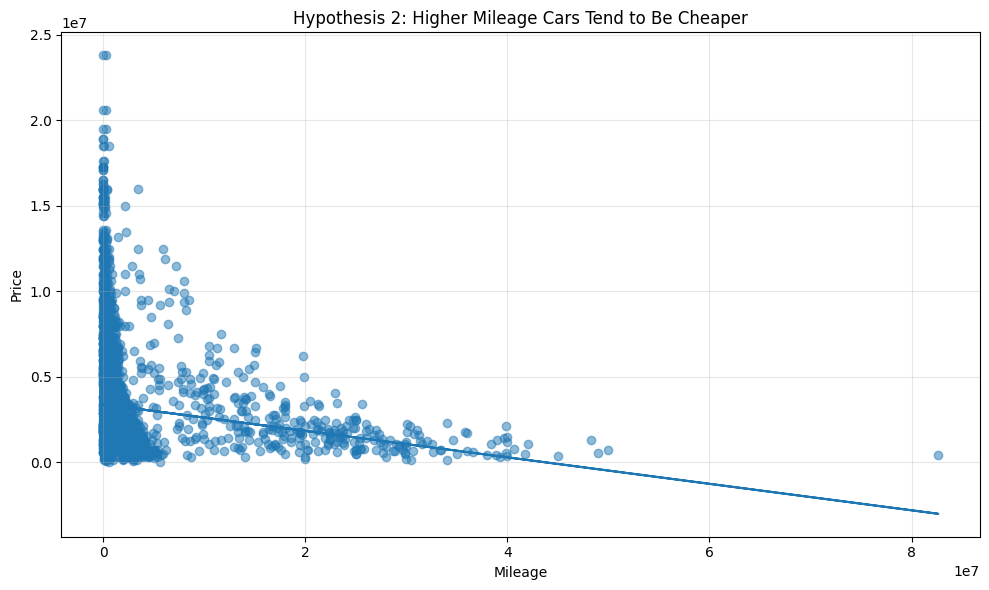

In [ ]:


print("=" * 80)
print("HYPOTHESIS 2")
print("=" * 80)

print("Hypothesis 2: Cars with higher mileage are cheaper.")

if all(col in df.columns for col in ["Mileage", "Price"]):
    clean_data = df[["Mileage", "Price"]].dropna()

    corr_mileage_price = clean_data["Mileage"].corr(clean_data["Price"])

    print(f"Correlation between Mileage and Price: {corr_mileage_price:.3f}")

    if corr_mileage_price < 0:
        print("Conclusion: Supported. Higher mileage is associated with lower prices.")
    else:
        print("Conclusion: Not supported.")

    plt.figure(figsize=(10, 6))
    plt.scatter(clean_data["Mileage"], clean_data["Price"], alpha=0.5)

    if len(clean_data) > 1:
        z = np.polyfit(clean_data["Mileage"], clean_data["Price"], 1)
        p = np.poly1d(z)
        plt.plot(clean_data["Mileage"], p(clean_data["Mileage"]))

    plt.title("Hypothesis 2: Higher Mileage Cars Tend to Be Cheaper")
    plt.xlabel("Mileage")
    plt.ylabel("Price")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/hypothesis_2_mileage_price.png", dpi=300)
    plt.show()

HYPOTHESIS 3
Hypothesis 3: AWD cars are more expensive than other drive types.
Original number of rows: 3402
Rows with valid drive values: 3397
Rows removed from Drive analysis: 5

Average price by drive type:


,count,mean_price,median_price,min_price,max_price
Drive,,,,,
awd,2099,"4,402,685.85","3,110,000.00",300000,24990000
front,113,"2,035,858.41","1,995,000.00",970000,6000000
rear,1185,"1,645,555.17","1,249,999.00",40000,10208000



AWD average price: 4,402,685.85
Other drive types average price: 1,679,533.80
Conclusion: Supported. AWD cars are more expensive on average.


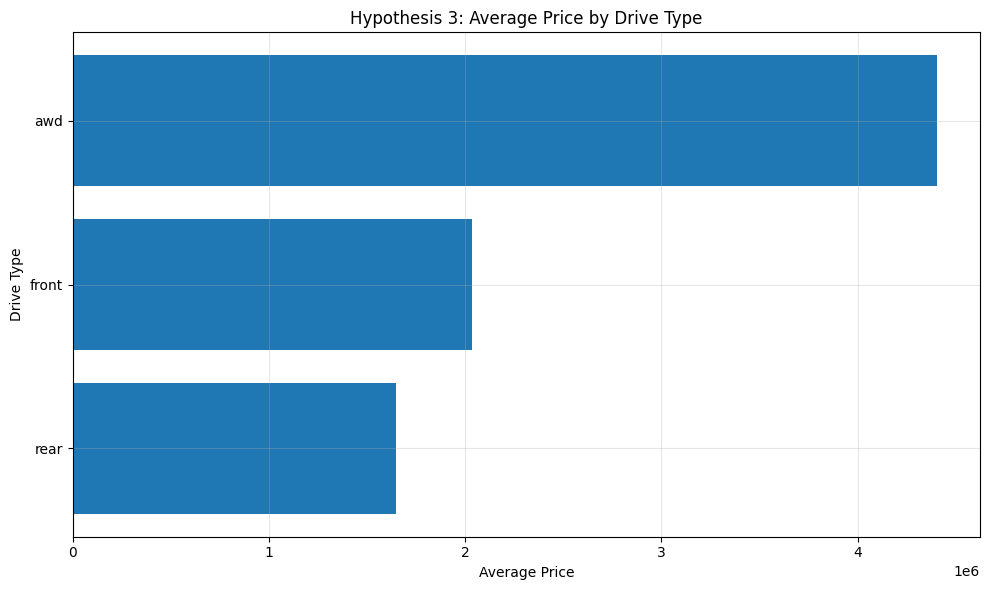

In [ ]:


print("=" * 80)
print("HYPOTHESIS 3")
print("=" * 80)

print("Hypothesis 3: AWD cars are more expensive than other drive types.")

if all(col in df.columns for col in ["Drive", "Price"]):

    valid_drive_values = ["awd", "front", "rear"]

    df_drive_clean = df[
        df["Drive"].astype(str).str.lower().isin(valid_drive_values)
    ].copy()

    print("Original number of rows:", len(df))
    print("Rows with valid drive values:", len(df_drive_clean))
    print("Rows removed from Drive analysis:", len(df) - len(df_drive_clean))

    drive_price = (
        df_drive_clean.groupby("Drive")
        .agg(
            count=("Price", "count"),
            mean_price=("Price", "mean"),
            median_price=("Price", "median"),
            min_price=("Price", "min"),
            max_price=("Price", "max")
        )
        .sort_values("mean_price", ascending=False)
    )

    print("\nAverage price by drive type:")
    display(drive_price)

    drive_price.to_csv(f"{OUTPUT_DIR}/hypothesis_3_drive_price_clean.csv")

    awd_data = df_drive_clean[df_drive_clean["Drive"].astype(str).str.lower() == "awd"]
    other_drive_data = df_drive_clean[df_drive_clean["Drive"].astype(str).str.lower() != "awd"]

    awd_mean = awd_data["Price"].mean()
    other_mean = other_drive_data["Price"].mean()

    print(f"\nAWD average price: {awd_mean:,.2f}")
    print(f"Other drive types average price: {other_mean:,.2f}")

    if awd_mean > other_mean:
        print("Conclusion: Supported. AWD cars are more expensive on average.")
    else:
        print("Conclusion: Not supported.")

    drive_plot = drive_price.sort_values("mean_price")

    plt.figure(figsize=(10, 6))
    plt.barh(drive_plot.index.astype(str), drive_plot["mean_price"])
    plt.title("Hypothesis 3: Average Price by Drive Type")
    plt.xlabel("Average Price")
    plt.ylabel("Drive Type")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/hypothesis_3_drive_price_clean.png", dpi=300)
    plt.show()

else:
    print("Cannot test: Drive or Price column is missing.")

In [ ]:
# ============================================================
# 17. FINAL SUMMARY
# ============================================================

print("=" * 80)
print("FINAL EDA SUMMARY")
print("=" * 80)

print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

print("\nNumerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

if "Price" in df.columns:
    print("\nAverage price:")
    print(f"{df['Price'].mean():,.2f}")

    print("\nMedian price:")
    print(f"{df['Price'].median():,.2f}")

    print("\nMinimum price:")
    print(f"{df['Price'].min():,.2f}")

    print("\nMaximum price:")
    print(f"{df['Price'].max():,.2f}")

if "Mileage" in df.columns:
    print("\nAverage mileage:")
    print(f"{df['Mileage'].mean():,.2f}")

    print("\nMedian mileage:")
    print(f"{df['Mileage'].median():,.2f}")

if "Price" in df.columns and len(df.select_dtypes(include=["int64", "float64"]).columns) > 1:
    print("\nStrongest correlations with Price:")
    display(df.select_dtypes(include=["int64", "float64"]).corr()["Price"].sort_values(ascending=False))

print("\nMain conclusions:")
print("1. The dataset contains car listings with information about title, year, engine, fuel, transmission, drive type, mileage, price, and location.")
print("2. Descriptive statistics were calculated for all numerical variables.")
print("3. The price distribution is right-skewed, meaning most cars are in lower or middle price ranges, while some cars are much more expensive.")
print("4. The log price distribution was used to reduce the effect of extreme car prices.")
print("5. Correlation analysis shows how price is related to year, mileage, engine size, and car age.")
print("6. Group-by analysis shows that average prices differ across fuel types, transmissions, drive types, car models, and locations.")
print("7. Top-N and bottom-N records helped identify unusually expensive, cheap, old, new, and high-mileage cars.")
print("8. Several hypotheses were tested using correlations, group comparisons, and visualizations.")

df.to_csv(f"{OUTPUT_DIR}/drom_final_with_eda_features.csv", index=False)

FINAL EDA SUMMARY
The dataset contains 3402 rows and 9 columns.

Numerical columns:
['Year', 'Engine', 'Mileage', 'Price']

Categorical columns:
['Title', 'Fuel', 'Transmission', 'Drive', 'Location']

Average price:
3,361,643.87

Median price:
2,097,000.00

Minimum price:
40,000.00

Maximum price:
24,990,000.00

Average mileage:
2,805,862.58

Median mileage:
530,000.00

Strongest correlations with Price:


,Price
Price,1.00
Year,0.67
Engine,0.04
Mileage,-0.16



Main conclusions:
1. The dataset contains car listings with information about title, year, engine, fuel, transmission, drive type, mileage, price, and location.
2. Descriptive statistics were calculated for all numerical variables.
3. The price distribution is right-skewed, meaning most cars are in lower or middle price ranges, while some cars are much more expensive.
4. The log price distribution was used to reduce the effect of extreme car prices.
5. Correlation analysis shows how price is related to year, mileage, engine size, and car age.
6. Group-by analysis shows that average prices differ across fuel types, transmissions, drive types, car models, and locations.
7. Top-N and bottom-N records helped identify unusually expensive, cheap, old, new, and high-mileage cars.
8. Several hypotheses were tested using correlations, group comparisons, and visualizations.
